In [1]:
from sensor_network_utils import * 
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
flowdata_paths = ['data/dailyflow_v3_1.csv', 'data/dailyflow_v3_2.csv']
df_cleaned, gauges_gdf, flowlines_gdf, usgs_index_df = load_data(
    flowdata_paths,
    'data/gage_12_shpaefile/SWIM_gage_loc_12.shp',
    'data/tx_gulf_flowlines/flowlines.shp',
    'data/gage_12.csv'
)

In [3]:
# Prepare USGS indices
usgs_location, usgs_number, columns_to_keep = prepare_usgs_indices(df_cleaned, usgs_index_df)


In [4]:
# Split data
X_train, X_test = split_data(df_cleaned.values)


In [5]:
# Get sensor placement 
sensor_location = sensor_placement_qr(X_train, int(usgs_number * 3))
sensor_location_expansion = sensor_placement_qr(X_train, int(usgs_number * 3), fixed_indices = list(usgs_location))

In [6]:
scale_factors = [1, 1.1, 1.25, 1.5, 1.75, 2, 2.5, 3]
sensor_counts = [int(usgs_number * factor) for factor in scale_factors]

In [7]:
sensor_loc_opt = {}
relative_errors_opt = {}

for n_sensors in sensor_counts:
    print(n_sensors)
    _, _, selected_sensors, _, _, relative_error = reconstruction_evaluation(X_train, X_test, sensor_location, n_sensors)
    sensor_loc_opt[n_sensors] = selected_sensors
    relative_errors_opt[n_sensors] = relative_error

447
491
558
670
782
894
1117
1341


In [8]:
sensor_loc_exp = {}
relative_errors_exp = {}

for n_sensors in sensor_counts:
    print(n_sensors)
    _, _, selected_sensors, _, _, relative_error = reconstruction_evaluation(X_train, X_test, sensor_location_expansion, n_sensors)
    sensor_loc_exp[n_sensors] = selected_sensors
    relative_errors_exp[n_sensors] = relative_error

447
491
558
670
782
894
1117
1341


In [9]:
diff = np.array([relative_errors_exp[key] - relative_errors_opt[key] for key in relative_errors_exp.keys()])

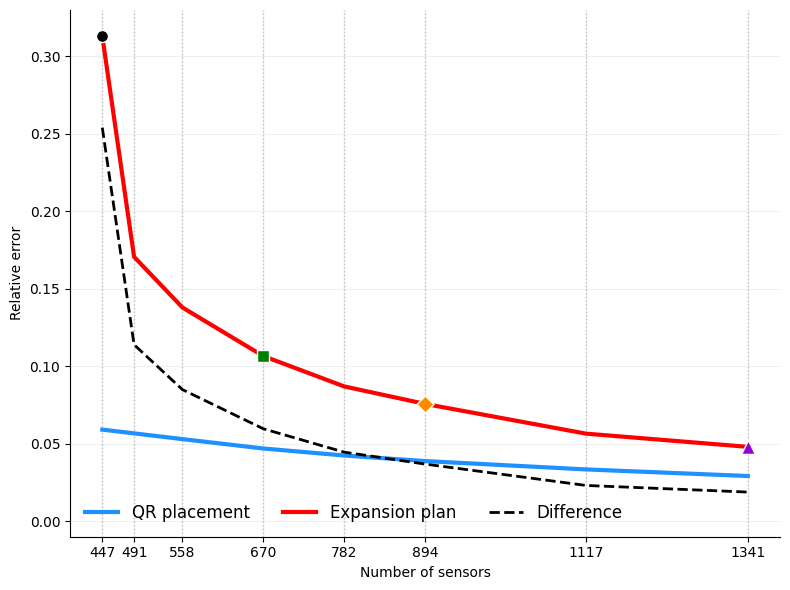

In [10]:
plt.figure(figsize=(8, 6), facecolor='none')

vertical_lines = relative_errors_exp.keys()
for line in vertical_lines:
    plt.axvline(x=line, color='silver', linestyle=':', linewidth=1)

# Plot data
plt.plot(list(relative_errors_opt.keys()), list(relative_errors_opt.values()), 
         color='dodgerblue', linewidth=3, linestyle='-', label='QR placement')
plt.plot(list(relative_errors_opt.keys()), list(relative_errors_exp.values()), 
         color='red', linewidth=3, linestyle='-', label='Expansion plan')

plt.scatter(list(relative_errors_exp.keys())[0], list(relative_errors_exp.values())[0], 
            color='black', edgecolor='white', marker='o', s=75, zorder=5)
plt.scatter(list(relative_errors_exp.keys())[3], list(relative_errors_exp.values())[3], 
            color='green', edgecolor='white', marker='s', s=75, zorder=5)
plt.scatter(list(relative_errors_exp.keys())[5], list(relative_errors_exp.values())[5], 
            color='darkorange', edgecolor='white', marker='D',s=75, zorder=5)
plt.scatter(list(relative_errors_exp.keys())[7], list(relative_errors_exp.values())[7], 
            color='darkviolet', edgecolor='white', marker='^', s=100, zorder=5)
plt.plot(list(relative_errors_opt.keys()), diff, 
         color='black', linewidth=2, linestyle='--', label='Difference')

plt.xticks(list(relative_errors_opt.keys()))
plt.xlabel('Number of sensors')
plt.ylabel('Relative error')
plt.legend(loc='lower left', frameon=False, fontsize=12, ncol=3)
plt.ylim(-0.01, 0.33)
plt.grid(alpha=0.2)
plt.tight_layout()

ax = plt.gca() 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('relative_error_plot.png', transparent=True, bbox_inches='tight', dpi=300)

plt.show()


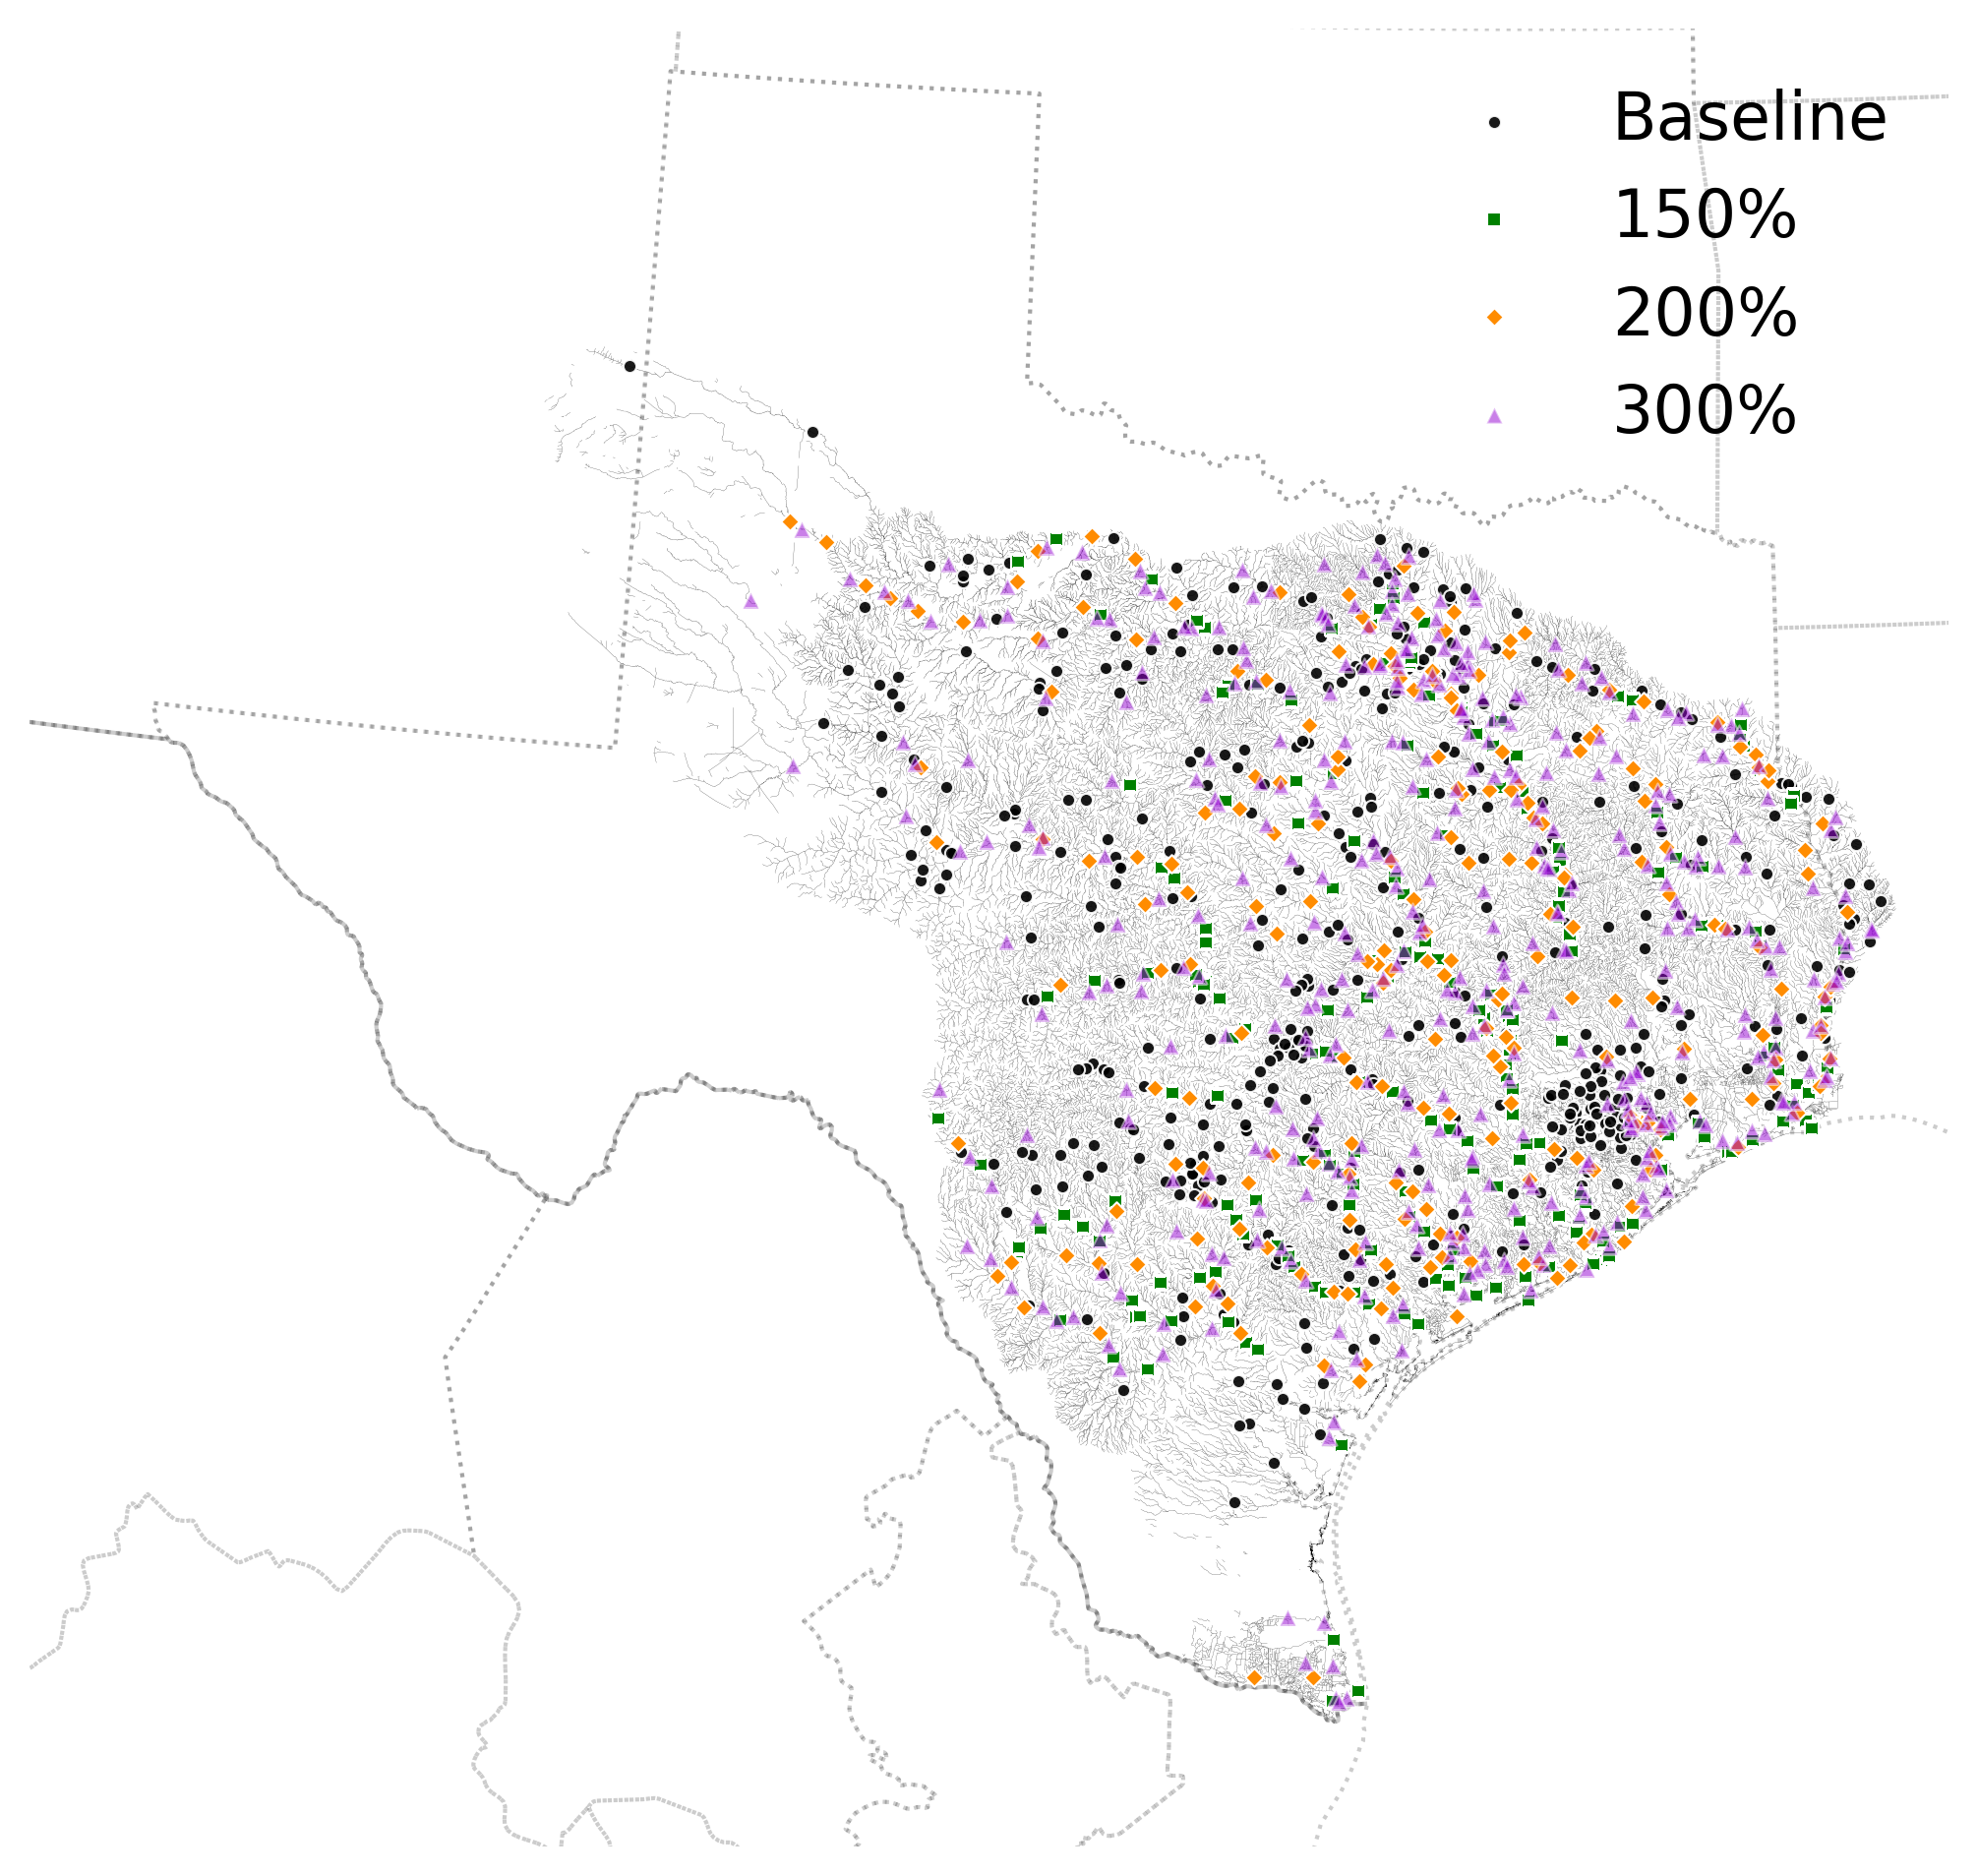

In [11]:
sensor_labels = {
    447: 'Baseline',  # Baseline
    670: '150%',      # 150%
    894: '200%',      # 200%
    1341: '300%'      # 300%
}

sensor_loc_exp_filtered = {k: sensor_loc_exp[k] for k in sensor_labels if k in sensor_loc_exp}

fig, ax = plot_sensor_network_expansion(
    flowlines_gdf=flowlines_gdf,
    df_cleaned=df_cleaned,
    sensor_locations_dict=sensor_loc_exp_filtered,
    sensor_labels=sensor_labels,
    save_path='sensor_network_expansion.png'
)